In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/mobile_sales.csv")
df.head()

,TransactionID,Date,MobileModel,Brand,Price,UnitsSold,TotalRevenue,CustomerAge,CustomerGender,Location,PaymentMethod
0,79397f68-61ed-4ea8-bcb2-f918d4e6c05b,2024-01-06,direction,Green Inc,1196.95,85,28002.80,32,Female,Port Erik,Online
1,4f87d114-f522-4ead-93e3-f336402df6aa,2024-04-05,right,Thomas-Thompson,1010.34,64,2378.82,55,Female,East Linda,Credit Card
2,6750b7d6-dcc5-48c5-a76a-b6fc9d540fe1,2024-02-13,summer,Sanchez-Williams,400.80,95,31322.56,57,Male,East Angelicastad,Online
3,7da7de95-f772-4cc2-bce0-b0873f98233e,2024-04-17,keep,Greer and Sons,338.60,79,31159.75,46,Other,East Kevin,Cash
4,469044af-0d60-4d87-af66-c6603e844057,2024-06-02,option,Brown and Sons,839.79,41,11523.36,38,Male,New Lindaborough,Online


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
df.info()
df.describe()

Shape: (1000, 11)

Columns: Index(['TransactionID', 'Date', 'MobileModel', 'Brand', 'Price', 'UnitsSold',
       'TotalRevenue', 'CustomerAge', 'CustomerGender', 'Location',
       'PaymentMethod'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   TransactionID   1000 non-null   object 
 1   Date            1000 non-null   object 
 2   MobileModel     1000 non-null   object 
 3   Brand           1000 non-null   object 
 4   Price           1000 non-null   float64
 5   UnitsSold       1000 non-null   int64  
 6   TotalRevenue    1000 non-null   float64
 7   CustomerAge     1000 non-null   int64  
 8   CustomerGender  1000 non-null   object 
 9   Location        1000 non-null   object 
 10  PaymentMethod   1000 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 86.1+ KB


,Price,UnitsSold,TotalRevenue,CustomerAge
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,807.512970,50.074000,40218.445040,41.141000
std,402.489878,28.616804,32715.290358,13.528346
min,103.320000,1.000000,116.850000,18.000000
25%,458.037500,25.000000,13316.037500,29.000000
50%,823.730000,51.000000,30860.655000,41.000000
75%,1157.875000,75.000000,60770.435000,53.000000
max,1499.250000,99.000000,141411.840000,64.000000


In [15]:
print("Missing Values:\n", df.isnull().sum())
df.ffill(inplace=True)

Missing Values:
 TransactionID     0
Date              0
MobileModel       0
Brand             0
Price             0
UnitsSold         0
TotalRevenue      0
CustomerAge       0
CustomerGender    0
Location          0
PaymentMethod     0
Month             0
dtype: int64


In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df['Month'] = df['Date'].dt.month

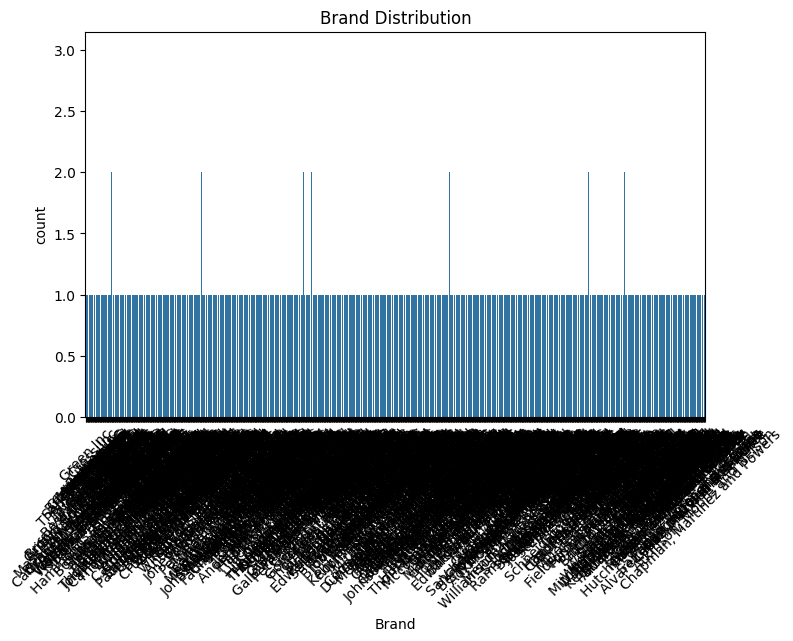

In [8]:
plt.figure(figsize=(8,5))
sns.countplot(x='Brand', data=df)
plt.xticks(rotation=45)
plt.title("Brand Distribution")
plt.show()

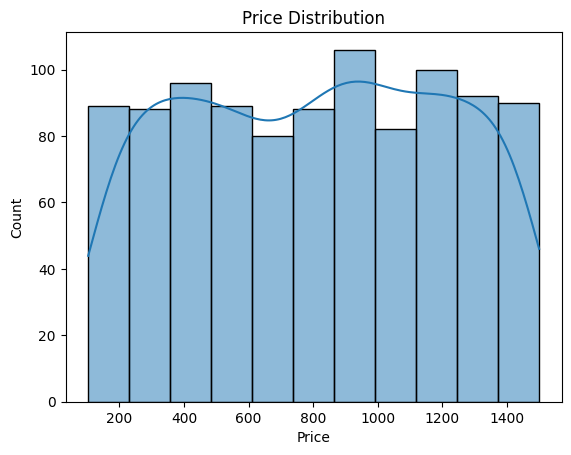

In [9]:
sns.histplot(df['Price'], kde=True)
plt.title("Price Distribution")
plt.show()

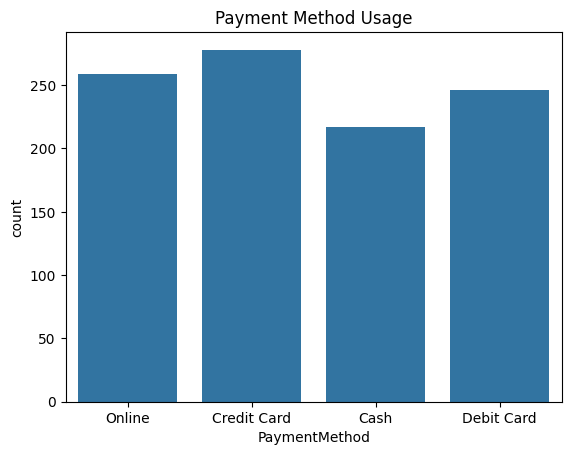

In [10]:
sns.countplot(x='PaymentMethod', data=df)
plt.title("Payment Method Usage")
plt.show()

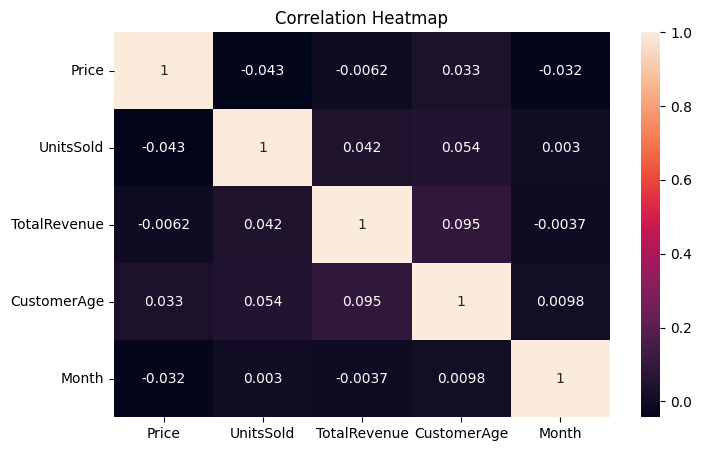

In [11]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

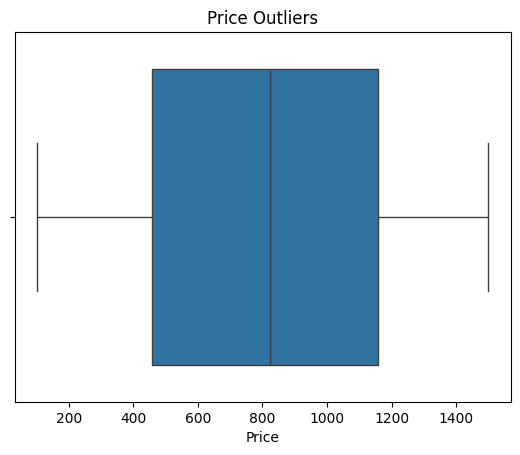

In [12]:
sns.boxplot(x=df['Price'])
plt.title("Price Outliers")
plt.show()

In [13]:
print("Top Brands:\n", df['Brand'].value_counts())
print("\nPayment Methods:\n", df['PaymentMethod'].value_counts())

Top Brands:
 Brand
Sanchez PLC                    3
Martinez Ltd                   3
Miller Ltd                     2
Ramos and Sons                 2
Williams Ltd                   2
                              ..
Perez and Sons                 1
Ayers and Sons                 1
Holland PLC                    1
Hill, Thompson and Anderson    1
Perry-Davis                    1
Name: count, Length: 980, dtype: int64

Payment Methods:
 PaymentMethod
Credit Card    278
Online         259
Debit Card     246
Cash           217
Name: count, dtype: int64


 Insights
1. Some brands have higher sales compared to others.
2. Online payment is used more frequently than other methods.
3. Price distribution shows most products fall within a certain range.
4. There is a relationship between price and total revenue.
5. Monthly sales trend varies across different months.

